In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def get_data():
    '''
    Function to genrate the synthetic data for the model development.
    '''
    no_of_rows = 4000
    
    timestamp = pd.date_range(start='2026-01-01', periods=no_of_rows, freq="1min")
    gas_level = np.random.normal(100, 50, no_of_rows)
    temperature = np.random.normal(60, 15, no_of_rows)
    pressure = np.random.normal(200, 40, no_of_rows)
    smoke_level = np.random.normal(5, 3, no_of_rows)   
    
    data = {
        "timestamp": timestamp,
        "gas_level": gas_level,
        "temperature": temperature,
        "pressure": pressure,
        "smoke_level": smoke_level    
    }
    

    return data

def data_to_df(data):
    '''
    Function to convert the data to dataframe.
    params:
        data: The data(dictionary) to be converted to dataframe.
    '''
    df = pd.DataFrame(data)
    
    df["alarm"] = (
        (df["gas_level"] > 250) |
        (df["smoke_level"] > 15) |
        (df["temperature"] > 90)
    ).astype(int)
    
    return df

def save_csv(df):
    '''
    Function to save the dataframe to csv file.
    params:
        df: The dataframe to be saved.
        file_path: The path to save the csv file.
    '''
    df.to_csv("raw_data.csv", index=False)

# Genrate the data:
data =get_data()
raw_df = data_to_df(data)

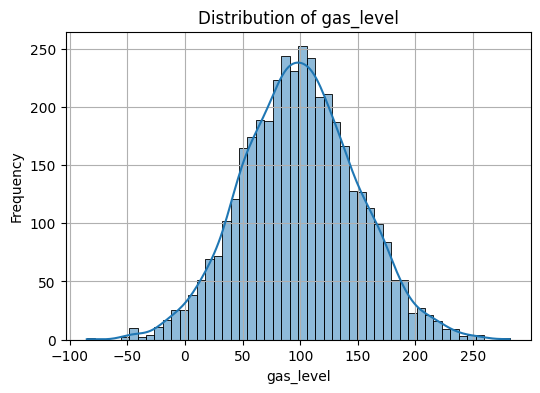

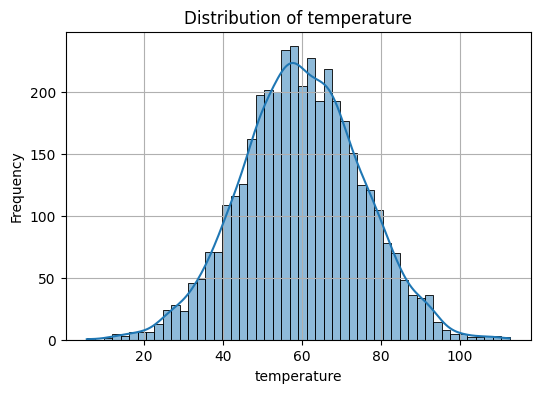

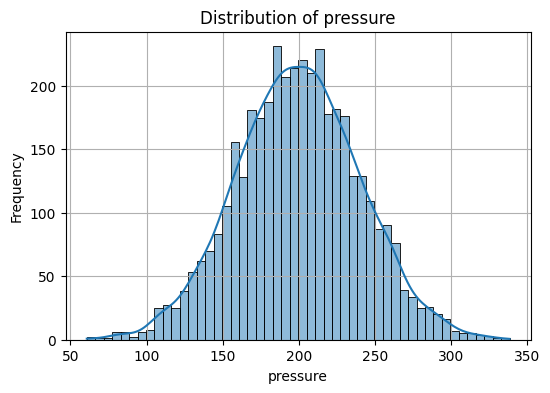

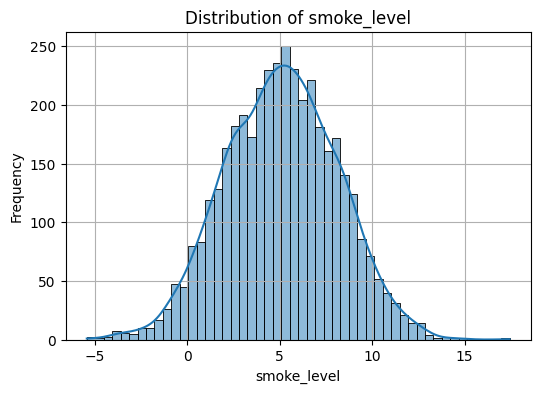

In [24]:
def plot_normal_distribution(df, exclude_cols=None):
    """
    Plots histogram + KDE (bell curve) for all numerical columns in the dataframe.
    
    params:
        df: pandas DataFrame
        exclude_cols: list of columns to exclude (e.g., ['alarm'])
    """
    
    if exclude_cols is None:
        exclude_cols = []
    
    # Select numerical columns
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    
    for col in num_cols:
        if col in exclude_cols:
            continue
        
        plt.figure(figsize=(6, 4))
        
        # Histogram + KDE
        sns.histplot(df[col], kde=True, bins=50)
        
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        
        plt.grid(True)
        plt.show()
    
plot_normal_distribution(raw_df, ["timestamp", "alarm"])

In [25]:
def clean_data(df):
    """
    End-to-end data cleaning pipeline (no row deletion).
    
    Steps:
    1. Fix data types
    2. Handle missing values
    3. Remove duplicates (without losing data)
    4. Fix invalid ranges
    5. Handle outliers (clip)
    6. Sort timestamp
    """

    df = df.copy()

    # -------------------------------
    # 1. Data Type Fix
    # -------------------------------
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # -------------------------------
    # 2. Handle Missing Values
    # -------------------------------
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns

    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())  # robust filling

    # -------------------------------
    # 3. Handle Duplicates (no drop)
    # -------------------------------
    # Add slight noise instead of dropping
    df = df.reset_index(drop=True)
    df["row_id"] = df.index  # maintain uniqueness

    # -------------------------------
    # 4. Range Validation + Fix
    # -------------------------------
    df["gas_level"] = df["gas_level"].clip(0, 500)
    df["temperature"] = df["temperature"].clip(0, 150)
    df["pressure"] = df["pressure"].clip(50, 400)
    df["smoke_level"] = df["smoke_level"].clip(0, 50)

    # -------------------------------
    # 5. Outlier Handling (smart capping)
    # -------------------------------
    for col in ["gas_level", "temperature", "pressure", "smoke_level"]:
        upper = df[col].quantile(0.99)
        df[col] = df[col].clip(upper=upper)

    # -------------------------------
    # 6. Timestamp Sorting
    # -------------------------------
    if "timestamp" in df.columns:
        df = df.sort_values(by="timestamp")

    # -------------------------------
    # 7. Final Consistency Check
    # -------------------------------
    df = df.reset_index(drop=True)

    return df

clean_df = clean_data(raw_df)

In [26]:
def check_ml_readiness(df, target_col="alarm"):
    print("🔍 ML Readiness Report\n")
    
    # -------------------------------
    # 1. Missing Values
    # -------------------------------
    missing = df.isnull().sum().sum()
    print(f"Missing Values: {missing}")
    
    # -------------------------------
    # 2. Data Types
    # -------------------------------
    print("\nData Types:")
    print(df.dtypes)
    
    # -------------------------------
    # 3. Duplicate Rows
    # -------------------------------
    duplicates = df.duplicated().sum()
    print(f"\nDuplicates: {duplicates}")
    
    # -------------------------------
    # 4. Target Variable Check
    # -------------------------------
    print("\nTarget Distribution:")
    print(df[target_col].value_counts(normalize=True))
    
    # -------------------------------
    # 5. Feature Summary
    # -------------------------------
    print("\nFeature Summary:")
    print(df.describe())
    
    # -------------------------------
    # 6. Correlation Check
    # -------------------------------
    print("\nCorrelation with target:")
    print(df.corr(numeric_only=True)[target_col].sort_values(ascending=False))
    
    # -------------------------------
    # 7. Range Check (basic)
    # -------------------------------
    print("\nRange Check:")
    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        print(f"{col}: min={df[col].min()}, max={df[col].max()}")
    
    print("\n✅ Check completed")
    
check_ml_readiness(clean_df)

🔍 ML Readiness Report

Missing Values: 0

Data Types:
timestamp      datetime64[us]
gas_level             float64
temperature           float64
pressure              float64
smoke_level           float64
alarm                   int64
row_id                  int64
dtype: object

Duplicates: 0

Target Distribution:
alarm
0    0.9735
1    0.0265
Name: proportion, dtype: float64

Feature Summary:
                 timestamp    gas_level  temperature     pressure  \
count                 4000  4000.000000  4000.000000  4000.000000   
mean   2026-01-02 09:19:30    99.942024    59.848061   199.584351   
min    2026-01-01 00:00:00     0.000000     5.563409    60.768190   
25%    2026-01-01 16:39:45    66.110062    49.707446   172.471615   
50%    2026-01-02 09:19:30    99.337872    59.628351   199.658610   
75%    2026-01-03 01:59:15   132.846484    69.981512   226.631865   
max    2026-01-03 18:39:00   217.899113    93.862452   294.747472   
std                    NaN    48.115544    14.951045

In [30]:
def prepare_ml_dataset(df):
    """
    Clean dataset for ML without:
    - Changing alarm logic
    - Adding extra columns
    - Dropping existing columns (except optional control)
    """

    df = df.copy()

    # -------------------------------
    # 1. Data Type Fix
    # -------------------------------
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # -------------------------------
    # 2. Handle Missing Values
    # -------------------------------
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())

    # -------------------------------
    # 3. Fix Invalid Ranges
    # -------------------------------
    df["gas_level"] = df["gas_level"].clip(0, 500)
    df["temperature"] = df["temperature"].clip(0, 150)
    df["pressure"] = df["pressure"].clip(50, 400)
    df["smoke_level"] = df["smoke_level"].clip(0, 50)

    # -------------------------------
    # 4. Handle Outliers (safe capping)
    # -------------------------------
    for col in ["gas_level", "temperature", "pressure", "smoke_level"]:
        upper = df[col].quantile(0.99)
        df[col] = df[col].clip(upper=upper)

    # -------------------------------
    # 5. Class Imbalance Report
    # -------------------------------
    if "alarm" in df.columns:
        print("📊 Class Distribution:")
        print(df["alarm"].value_counts(normalize=True))

    print("\n✅ Data ready for ML (no extra columns added)")

    return df

ml_ready_df = prepare_ml_dataset(raw_df)

📊 Class Distribution:
alarm
0    0.9735
1    0.0265
Name: proportion, dtype: float64

✅ Data ready for ML (no extra columns added)


In [31]:
ml_ready_df.head()

,timestamp,gas_level,temperature,pressure,smoke_level,alarm
0,2026-01-01 00:00:00,73.826188,73.581532,119.475976,1.402359,0
1,2026-01-01 00:01:00,97.534191,51.297465,201.612411,8.068864,0
2,2026-01-01 00:02:00,22.987395,49.437718,137.512840,5.880368,0
3,2026-01-01 00:03:00,165.093065,69.506179,269.784996,9.827446,0
4,2026-01-01 00:04:00,48.666077,44.612271,246.767803,6.524437,0


In [32]:
ml_ready_df["alarm"].value_counts()

alarm
0    3894
1     106
Name: count, dtype: int64

In [34]:
ml_ready_df.to_csv("raw_data.csv", index=False)